# Case-05：二層對稱剛架 (Two-Story Symmetric Frame)

承接 Case-03，本 Case 多一層樓——結構跟載重都左右對稱，所以整體仍然無側移，但轉角未知量從 2 個變成 4 個 (θ_B, θ_C, θ_D, θ_E)。

## 題目摘要
| 項目 | 內容 |
|---|---|
| 結構 | 二層一跨剛架，A、F兩柱底固定 |
| H1(一樓層高) | 4.0 m |
| H2(二樓層高) | 3.5 m |
| L(跨度) | 6.0 m |
| w1(一樓梁均佈載重) | 24.0 kN/m |
| w2(屋頂梁均佈載重) | 18.0 kN/m |
| Dk (獨立位移自由度) | 4 (θ_B, θ_C, θ_D, θ_E，無側移) |

## 本 Case 新增的概念
不預設 $\theta_B=-\theta_E$、$\theta_C=-\theta_D$ 這種鏡像對稱關係，讓四條節點力矩平衡方程式自己解出來——解出來的結果會自然呈現這種鏡像對稱，這是驗證答案合理性的依據，不是事先假設的捷徑。

## FEM 慣例
近端負、遠端正，跟 Case-01~04.5 統一。

## 0. 安裝套件

In [1]:
try:
    import anastruct
    print("已偵測到 anastruct，略過安裝")
except ImportError:
    print("未偵測到 anastruct，開始安裝...")
    !pip install anastruct -q --break-system-packages
    try:
        import anastruct
        print("安裝完成，可以繼續往下執行")
    except ImportError:
        print("安裝後仍無法載入，這是 Colab 偶爾會發生的快取問題，"
              "請直接重新執行這個 cell 一次（通常第二次就會成功）")

%matplotlib inline

已偵測到 anastruct，略過安裝


## 1. 框架本體 (與其他 Case 共用)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from abc import ABC, abstractmethod

sp.init_printing()

# ============================================================
# 環境偵測：同一份程式碼要能在 Jupyter/Colab (有 IPython kernel，
# display()/plt.show() 都能正常渲染) 跟純終端機/VSCode直接執行
# (python3 xxx.py，沒有IPython kernel，display()只會印物件repr、
# plt.show()在沒有視窗系統時什麼都不會顯示) 兩種環境都正常運作。
# ============================================================
try:
    from IPython import get_ipython
    _ipy = get_ipython()
    IN_NOTEBOOK = _ipy is not None and hasattr(_ipy, 'kernel')
except ImportError:
    IN_NOTEBOOK = False

if IN_NOTEBOOK:
    from IPython.display import Markdown, display
else:
    class Markdown:
        """純終端機環境用的Markdown替代品：只存文字，print時原樣印出
        (不渲染標題#、粗體**這些語法，但內容完整可讀)。"""
        def __init__(self, text):
            self.text = text

    def display(obj):
        """純終端機環境用的display()替代品："""
        if isinstance(obj, Markdown):
            print(obj.text)
        elif isinstance(obj, sp.Basic):
            sp.pprint(obj)
        else:
            print(obj)

_fig_counter = [0]


def _show_fig(prefix="figure"):
    """
    取代裸的 plt.show()：Jupyter/Colab 環境正常顯示；純終端機環境沒有
    畫面可以顯示，改成存檔到當前目錄並印出檔名，不會讓圖「憑空消失」。
    """
    if IN_NOTEBOOK:
        plt.show()
    else:
        _fig_counter[0] += 1
        fname = f"{prefix}_{_fig_counter[0]}.png"
        plt.gcf().savefig(fname, dpi=110, bbox_inches='tight')
        print(f"[圖已存檔: {fname}]")
        plt.close()


# ============================================================
# 通用互動輸入：只用 input()，不依賴 ipywidgets 這種只有特定 notebook
# 環境才有的東西——Colab、純 Linux 終端機(python3 xxx.py)、VSCode
# (不管是 Jupyter 分頁還是直接跑 .py 檔) 全部都能動。
# ============================================================
def prompt_for_params(param_specs):
    """
    param_specs: list of (name, description, default, type_cast)
    互動詢問每個參數，直接按 Enter 就用預設值。回傳 dict {name: value}。
    """
    print("=" * 50)
    print("互動輸入（直接按 Enter 使用預設值）")
    print("=" * 50)
    result = {}
    for name, desc, default, cast in param_specs:
        raw = input(f"{name} ({desc}) [預設 {default}]: ").strip()
        try:
            result[name] = cast(raw) if raw else default
        except ValueError:
            print(f"  輸入無法轉換，使用預設值 {default}")
            result[name] = default
    print("=" * 50)
    for k, v in result.items():
        print(f"  {k} = {v}")
    print("=" * 50)
    return result


# ============================================================
# 共用工具：桿件彎矩沿長度的分布 (含均佈載重 w 的一般化版本)
# ============================================================
def member_moment_curve(s, length, w, M_i, M_j):
    """
    計算桿件內部彎矩沿桿長的分布 M(s)，s 為由 i 端起算的局部座標 (0~length)。
    - 無側向載重 (w=0)：退化為 i, j 兩端值的線性內插 (柱、無載重梁適用)
    - 有均佈載重 w (力/長度)：抵滿足 M(0)=M_i, M(L)=M_j 邊界條件的拋物線
      (由 d²M/ds² = w 積分兩次求得)，可正確反映跨中彎矩，而不是被兩端值
      的直線內插蓋掉 (這對兩端彎矩接近正負對稱、但跨中另有較大彎矩的
      受均佈載重梁尤其重要)。
    """
    C1 = (M_j - M_i - 0.5 * w * length**2) / length
    return M_i + C1 * s + 0.5 * w * s**2


def member_shear_curve(s, length, w, M_i, M_j):
    """
    member_moment_curve 的對應剪力函式: V(s) = dM/ds = C1 + w*s
    (跟彎矩用同一個 C1，兩者必須自洽——這也是為什麼前幾輪都用剪力
    去反查彎矩圖畫法對不對的原因：M(s) 和 V(s) 本來就是同一個 C1
    推出來的，不會不一致)
    """
    C1 = (M_j - M_i - 0.5 * w * length**2) / length
    return C1 + w * s


def member_offset_curve(x0, y0, x1, y1, s, m_values, scale):
    """
    通用的桿件內力圖偏移座標計算，取代過去每個Case各自手寫的x/y偏移公式
    （柱一套、梁又一套，還常常寫錯方向）。

    這個函式畫出來的圖是「拉力彎矩圖」(Tension-Side Bending Moment
    Diagram)：偏移方向就是該處實際受拉的那一側，不是單純套一個數學
    座標正負號——已經用最單純無爭議的案例（懸臂梁，全長已知受拉側
    唯一）驗證過 anastruct 本身就是這樣畫的，我們的規則是照anastruct
    的實際輸出反推校準出來的，跟它一致。這也是為什麼看這張圖就能
    直接判斷配筋位置，不用再心算正負號對應哪一側。

    規則: 偏移方向 = 沿著桿件「近端(x0,y0)→遠端(x1,y1)」前進方向，
    逆時針轉90度，正值往這個方向偏移。這個規則套用在水平桿件（近端
    到遠端由左到右）會自動算出「正值往上偏移」，套用在垂直桿件（近端
    到遠端由下到上）會自動算出「正值往左偏移」——這對任意角度的桿件
    都適用，包括未來斜屋頂剛架(S-01)需要的斜桿件。

    參數:
      x0,y0,x1,y1: 桿件近端、遠端的座標
      s: 沿桿件長度的局部座標陣列 (0~length)
      m_values: 對應每個s的彎矩或剪力值 (通常是 member_moment_curve
                或 member_shear_curve 的輸出)
      scale: 縮放比例
    回傳: (x, y) 畫圖用座標陣列
    """
    length = np.hypot(x1 - x0, y1 - y0)
    dx, dy = (x1 - x0) / length, (y1 - y0) / length
    perp_x, perp_y = -dy, dx  # 逆時針90度
    frac = s / length
    base_x = x0 + frac * (x1 - x0)
    base_y = y0 + frac * (y1 - y0)
    return base_x + perp_x * m_values * scale, base_y + perp_y * m_values * scale


# ============================================================
# 策略介面 (Strategy Interface)
# ============================================================
class SlopeDeflectionProblem(ABC):
    """
    傾角變位法問題的策略介面。
    每一種結構模型（單層側移剛架、二層重力剛架...）只需要繼承這個類別，
    把「模型特有」的部分實作出來；共用的「步驟1~6」解題流程交給
    SlopeDeflectionSolver（Template Method）負責，輸出格式統一比照
    手寫詳解的呈現方式。
    """

    @abstractmethod
    def get_unknowns(self) -> dict:
        """回傳未知位移量的 sympy 符號，例如 {'theta_B': ...}"""

    @abstractmethod
    def describe(self) -> str:
        """題目文字敘述 (Markdown)：結構、幾何、材料、載重、邊界條件，用於步驟1。
        不含自由度選取的說明——那部分獨立在 describe_dof()。"""

    @abstractmethod
    def describe_dof(self) -> str:
        """
        自由度(未知位移量)選取的說明 (Markdown)，用於步驟1。跟 describe()
        分開成獨立方法，是因為這一步是整個傾角變位法最容易出錯、也最該
        覆核的地方——自由度選錯或漏掉一個，後面所有方程式都會建立在錯誤
        的基礎上，整題就全錯了，值得在輸出裡獨立成一個顯眼的區塊，
        不要被埋沒在結構描述裡面。
        """

    @abstractmethod
    def draw_geometry(self, ax):
        """畫結構幾何圖 (圖1)，用於步驟1"""

    @abstractmethod
    def build_moment_equations(self) -> dict:
        """回傳桿端彎矩符號運算式 {'M_{AB}': expr, ...}，用於步驟2"""

    @abstractmethod
    def build_equilibrium_equations(self, moments: dict) -> list:
        """
        回傳平衡方程式，用於步驟3。格式為 list[tuple[str, sp.Eq]]：
        每一條方程式搭配一句說明它是哪個節點/桿件、哪一種平衡條件
        (例如 "節點B力矩平衡 ΣM_B=0"、"C端邊界條件(滾支承) M_CB=0"、
        "整體水平力平衡 ΣFx=0")，求解器會把說明跟方程式一起印出來，
        不再只丟一堆沒有上下文的裸方程式。
        """

    def compute_reactions(self, moments_val: dict) -> dict:
        """(可選) 由彎矩回代算支承反力/軸力，用於步驟5。預設不計算。"""
        return {}

    @abstractmethod
    def draw_bmd(self, ax, moments_val: dict):
        """畫彎矩圖 (圖2)，用於步驟6"""

    def draw_sfd(self, ax, moments_val: dict) -> bool:
        """
        (可選) 畫剪力圖 (SFD)，用於步驟6。若模型有實作，回傳 True 並把圖
        畫進傳入的 ax；預設不提供 (回傳 False)，求解器會印出提示而不出圖。
        """
        return False

    def draw_tension_side(self, ax, moments_val: dict) -> bool:
        """
        (可選) 在結構圖上直接標註每個桿端的受拉/受壓側 (拉力彎矩圖的
        文字版對照)，若模型有實作，回傳 True 並把圖畫進傳入的 ax；
        預設不提供 (回傳 False)。適合搭配 member_offset_curve 的偏移
        方向來自動判斷: 偏移方向那一側 = 受拉側 (已用懸臂梁這種答案
        唯一的案例驗證過 anastruct 真的是這樣畫的)。
        """
        return False

    def draw_deformed_shape(self, ax, moments_val: dict, solution: dict) -> bool:
        """
        (可選) 在同一張圖上疊加「原始結構 + 變形後形狀」。若模型有實作，
        回傳 True 並把圖畫進傳入的 ax；預設不提供 (回傳 False)。

        做法：對每根桿件，用拉力側 M(s) 轉成材料力學 sagging 慣例
        (M_sag=-M_hog)，積分兩次 EI*u''=M_sag 得到「桿件局部座標系
        正方向」(近端->遠端逆時針轉90度) 的橫向位移，邊界條件依各桿件
        的支承/連接方式而定 (case-specific，沒辦法通用化)。**算出來的
        u(s) 一定要再套 member_offset_curve 轉成畫圖座標，不能直接當
        全域x或y用**——這是實際踩過的坑：柱子的近端->遠端方向是垂直的，
        逆時針轉90度後的「正方向」其實是全域-x，直接套全域+x會整個
        鏡像顛倒(已用anastruct的show_displacement()實際畫圖座標逐點
        驗證過，修正後精確吻合)。
        """
        return False

    def teaching_breakdown(self, moments_val: dict, reactions: dict, solution: dict) -> list:
        """
        (可選) 回傳這個模型的「教學詳解 + 評分要點」分解，用於步驟8。
        每個小題是一個 dict，需要以下 key：
          - title:         小題標題 (str)
          - problem:       題目敘述 (str)
          - concept:       概念解析 (str)
          - formula:       公式引用 (str, 可含 LaTeX)
          - substitution:  帶入數據說明 (str)
          - answer:        詳細參考答案 (str, 可含 LaTeX)
          - keywords:       關鍵字/chunk 列表 (list[str])
          - grading:        評分要點列表 (list[tuple[str, int]])，每項是
                            (要點敘述, 配分)
        預設回傳空列表 (不提供)，求解器會印出提示而不出教學詳解——
        這是刻意設計成可選的，因為每題的概念解析、配分是需要針對該
        Case 手動設計的教學內容，不是所有 Case 一開始就要準備好。
        """
        return []


# ============================================================
# Template Method：共用的「步驟1~6」解題骨架
# ============================================================
class SlopeDeflectionSolver:
    """
    通用傾角變位法求解器 (Template Method)。
    計算內容全部委託給傳入的 SlopeDeflectionProblem（Strategy），
    這個類別只負責固定不變的六步驟框架與統一格式的美化輸出。
    """

    def __init__(self, problem: SlopeDeflectionProblem):
        self.problem = problem

    @staticmethod
    def _step_header(n, title):
        print("\n" + "=" * 60)
        print(f"【步驟 {n}】{title}")
        print("=" * 60)

    def _solve_core(self):
        """純計算，不印任何東西：算出 moments、平衡方程式、解、回代結果、反力。
        solve_and_report() 跟 print_teaching_handout() 共用這段，避免兩邊各算一次
        還可能算出不一樣結果的風險。"""
        p = self.problem
        moments = p.build_moment_equations()
        labeled_eqs = p.build_equilibrium_equations(moments)
        eqs = [eq for _, eq in labeled_eqs]
        unknowns = p.get_unknowns()
        sol = sp.solve(eqs, tuple(unknowns.values()))
        moments_val = {name: float(expr.subs(sol)) for name, expr in moments.items()}
        reactions = p.compute_reactions(moments_val)
        return moments, labeled_eqs, unknowns, sol, moments_val, reactions

    @staticmethod
    def _annotate_tension_note(ax):
        """
        在彎矩圖上加一行小提示，說明這張圖是拉力側繪製慣例——用英文避免
        matplotlib預設字型(DejaVu Sans)缺中文字產生的警告(之前踩過這個坑，
        中文標題會在Colab印出一長串UserWarning)。詳細的中文說明放在
        print_teaching_handout()的Markdown文字裡，那邊走的是Markdown/HTML
        渲染，沒有這個字型限制。
        """
        ax.text(0.5, -0.08, 'Bending moment diagram drawn on the tension side',
                transform=ax.transAxes, ha='center', fontsize=8.5,
                color='dimgray', style='italic')

    def _print_teaching_breakdown(self, moments_val, reactions, sol):
        """渲染 teaching_breakdown() 的內容 (題目/概念解析/公式引用/帶入數據/
        參考答案/關鍵字/評分要點)。solve_and_report() 的步驟8跟
        print_teaching_handout() 共用這段渲染邏輯，回傳 True/False 代表這個
        model 有沒有提供內容。"""
        p = self.problem
        breakdown = p.teaching_breakdown(moments_val, reactions, sol)
        if not breakdown:
            return False
        total_points = 0
        for i, item in enumerate(breakdown, 1):
            display(Markdown(f"### 第{i}小題：{item['title']}"))
            display(Markdown(f"**題目**：{item['problem']}"))
            display(Markdown(f"**概念解析**：{item['concept']}"))
            display(Markdown(f"**公式引用**：\n\n{item['formula']}"))
            display(Markdown(f"**帶入數據**：{item['substitution']}"))
            display(Markdown(f"**詳細參考答案**：\n\n{item['answer']}"))
            display(Markdown(f"**關鍵字/chunk**：{', '.join(item['keywords'])}"))
            pts_sum = sum(pts for _, pts in item['grading'])
            grading_lines = "\n".join(f"- {desc}（{pts}分）" for desc, pts in item['grading'])
            display(Markdown(f"**評分要點**（本小題共 {pts_sum} 分）：\n\n{grading_lines}"))
            total_points += pts_sum
        display(Markdown(f"---\n**本題總分：{total_points} 分**"))
        return True

    def print_teaching_handout(self):
        """
        產生一份純粹「繪圖」的教學輸出，不含文字推導、不含評分要點，只有
        五張圖 (a~e)，適合放在 solve_and_report() 那個 cell 的下一個 cell，
        單獨執行、單獨截圖/複製：
          a. 結構受力圖
          b. 剪力圖 (SFD)
          c. 彎矩圖 (BMD)
          d. 拉力側標註圖
          e. 變形圖
        """
        p = self.problem
        moments, labeled_eqs, unknowns, sol, moments_val, reactions = self._solve_core()

        display(Markdown("### a. 結構受力圖"))
        fig1, ax1 = plt.subplots(figsize=(8, 6))
        p.draw_geometry(ax1)
        _show_fig("structure")

        display(Markdown("### b. 剪力圖 (SFD)"))
        fig_sfd, ax_sfd = plt.subplots(figsize=(8, 5))
        has_sfd = p.draw_sfd(ax_sfd, moments_val)
        if has_sfd:
            _show_fig("sfd")
        else:
            plt.close(fig_sfd)
            print("(此模型尚未實作剪力圖，略過)")

        display(Markdown("### c. 彎矩圖 (BMD)"))
        fig2, ax2 = plt.subplots(figsize=(8, 6))
        p.draw_bmd(ax2, moments_val)
        self._annotate_tension_note(ax2)
        _show_fig("bmd")
        plt.close('all')

        display(Markdown("### d. 拉力側標註圖"))
        fig_t, ax_t = plt.subplots(figsize=(8, 7))
        has_tension = p.draw_tension_side(ax_t, moments_val)
        if has_tension:
            _show_fig("tension_side")
        else:
            plt.close(fig_t)
            print("(此模型尚未實作拉力側標註圖，略過)")

        display(Markdown("### e. 變形圖"))
        fig_d, ax_d = plt.subplots(figsize=(8, 7))
        has_deformed = p.draw_deformed_shape(ax_d, moments_val, sol)
        if has_deformed:
            _show_fig("deformed")
        else:
            plt.close(fig_d)
            print("(此模型尚未實作變形圖，略過)")

    def solve_and_report(self):
        p = self.problem

        # ---------------- 步驟1：題目與幾何 ----------------
        self._step_header(1, "題目定義、幾何/材料參數與自由度標示")
        display(Markdown("**① 結構定義、幾何與邊界條件**"))
        display(Markdown(p.describe()))
        fig1, ax1 = plt.subplots(figsize=(8, 6))
        p.draw_geometry(ax1)
        _show_fig("structure")
        display(Markdown(
            "**② ⚠️ 自由度選取**（這一步選錯或漏掉，後面所有方程式都會建立在"
            "錯誤基礎上、整題全錯，是最需要覆核的一步）：\n\n" + p.describe_dof()
        ))

        # ---------------- 步驟2：桿端彎矩方程式 ----------------
        self._step_header(2, "寫出桿端彎矩方程式")
        display(Markdown(
            "**① 公式引用**（傾角變位法一般式，對任何桿件 i→j 都適用，跟結構種類無關）：\n\n"
            r"$$M_{ij} = \frac{2EI}{L}\left(2\theta_i + \theta_j - 3\psi\right) + FEM_{ij}$$"
            "\n\n其中 $\\theta_i,\\theta_j$ 為兩端轉角，$\\psi=\\Delta/L$ 為側移角"
            "（無側移時 $\\psi=0$），$FEM_{ij}$ 為固定端彎矩(依載重種類查表)。"
        ))
        moments, labeled_eqs, unknowns, sol, moments_val, reactions = self._solve_core()
        display(Markdown(
            "**② 代入本題的邊界條件、跨長與載重**，得到每根桿件的具體算式："
        ))
        for name, expr in moments.items():
            display(sp.Eq(sp.Symbol(name), expr))

        # ---------------- 步驟3：平衡方程式 ----------------
        self._step_header(3, "建立平衡方程式")
        display(Markdown("**平衡方程式**（每條方程式對應哪個節點/桿件、哪一種平衡條件）："))
        for label, eq in labeled_eqs:
            display(Markdown(f"- {label}"))
            display(eq)

        # ---------------- 步驟4：解聯立方程式 ----------------
        self._step_header(4, "求解聯立方程式 (未知位移量)")
        display(Markdown("**① 符號解**（保留 EI 符號，這是傾角變位法教學上的標準步驟——"
                          "對單一材料/均勻EI的靜不定結構，解出來的桿端彎矩最終會跟EI無關，"
                          "所以先看符號解能清楚看出這個特性）："))
        for name, sym in unknowns.items():
            display(sp.Eq(sp.Symbol(name), sol[sym]))

        EI_numeric = getattr(p, 'EI_numeric', None)
        if EI_numeric is not None:
            display(Markdown(
                f"**② 代入 EI 數值**（EI = {EI_numeric}，方便直接跟 anastruct、"
                "OpenSeesPy 這類數值工具的結果對照，不用自己心算分數/小數）："
            ))
            for name, sym in unknowns.items():
                val_numeric = float(sol[sym].subs(p.EI, EI_numeric))
                display(sp.Eq(sp.Symbol(name), round(val_numeric, 6)))

        # ---------------- 步驟5：回代求彎矩與反力 ----------------
        self._step_header(5, "計算真實桿端彎矩與反力")
        display(Markdown("**最終桿端彎矩計算結果 (kN·m)：**"))
        for name, val in moments_val.items():
            print(f"{name} = {val:.3f} kN·m")

        if reactions:
            print()
            for name, val in reactions.items():
                print(f"-> {name} = {val:.3f}")

        # ---------------- 步驟6：剪力圖、彎矩圖已移到 print_teaching_handout() ----------------
        # 手算詳解專注在推導過程本身，圖放在下一個cell的教學講義裡，避免重複

        return {"moments": moments_val, "reactions": reactions, "solution": sol}


## 2. Case-05 模型 (Strategy)

In [3]:
import numpy as np
import sympy as sp



class TwoStoryFrameProblem(SlopeDeflectionProblem):
    """
    Case-05：二層對稱剛架 (Two-Story Symmetric Frame)
    節點: A,F底層固定; B,E一樓樓板高度(H1); C,D屋頂高度(H1+H2)
    柱: AB(一樓左), FE(一樓右), BC(二樓左), ED(二樓右)
    梁: BE(一樓梁,均佈載重w1), CD(屋頂梁,均佈載重w2)

    結構對稱、載重對稱(w1、w2左右一致) -> 無側移(psi=0全部柱子)，
    4個未知數 theta_B, theta_C, theta_D, theta_E(不假設對稱關係，
    讓方程式自己解出來——解出來會自動呈現 theta_B=-theta_E,
    theta_C=-theta_D 這種鏡像關係，不用事先假設)。

    FEM慣例：近端負、遠端正(傳統教科書慣例)，跟Case-01~04.5統一。
    """

    def __init__(self, H1=4.0, H2=3.5, L=6.0, w1=24.0, w2=18.0, EI_numeric=15000.0):
        self.H1, self.H2, self.L, self.w1, self.w2 = H1, H2, L, w1, w2
        self.EI = sp.Symbol('EI', positive=True, real=True)
        (self.theta_B, self.theta_C, self.theta_D, self.theta_E) = sp.symbols(
            'theta_B theta_C theta_D theta_E', real=True)
        self.EI_numeric = EI_numeric

    def get_unknowns(self):
        return {'\\theta_B': self.theta_B, '\\theta_C': self.theta_C,
                '\\theta_D': self.theta_D, '\\theta_E': self.theta_E}

    def describe(self):
        return (f"**一樓層高** $H_1={self.H1}$ m，**二樓層高** $H_2={self.H2}$ m，"
                f"**跨度** $L={self.L}$ m\n\n"
                f"**一樓梁均佈載重** $w_1={self.w1}$ kN/m，"
                f"**屋頂梁均佈載重** $w_2={self.w2}$ kN/m\n\n"
                f"**邊界條件：** A、F兩端固定 ($\\theta_A=\\theta_F=0$)")

    def describe_dof(self):
        return (f"結構左右對稱、載重也左右對稱(w1、w2都是左右一致的均佈載重)，"
                f"所以**整體無側移**(兩層樓的側移角都是0，不用額外設Δ這個"
                f"未知量)——這點跟Case-04(側移剛架)不同，反而更接近Case-03的"
                f"情況，只是多了一層樓、多了兩個轉角未知量。\n\n"
                f"四個梁柱交會的剛性節點 B、C、D、E 各自有一個轉角未知量，"
                f"**不假設對稱關係**(不預設 $\\theta_B=-\\theta_E$ 這種鏡像"
                f"關係)，讓四條節點力矩平衡方程式自己解出來——解出來的結果"
                f"會自然呈現這種鏡像對稱，這是驗證答案合理性的依據，不是"
                f"事先假設的捷徑。共 $\\theta_B,\\theta_C,\\theta_D,\\theta_E$ "
                f"四個未知位移量。")

    def draw_geometry(self, ax):
        H1, H2, L = self.H1, self.H2, self.L
        Htot = H1 + H2
        ax.plot([0, 0], [0, Htot], 'k-', lw=3)
        ax.plot([L, L], [0, Htot], 'k-', lw=3)
        ax.plot([0, L], [H1, H1], 'k-', lw=3)
        ax.plot([0, L], [Htot, Htot], 'k-', lw=3)
        for x0 in (0, L):
            ax.plot([x0 - 0.15, x0 + 0.15], [-0.02, -0.02], 'k-', lw=3)
            for dx in np.linspace(-0.12, 0.12, 5):
                ax.plot([x0 + dx, x0 + dx - 0.1], [0, -0.2], 'k-', lw=1)
        ax.text(0, -0.5, 'A (Fixed)', ha='center', fontsize=9, fontweight='bold')
        ax.text(L, -0.5, 'F (Fixed)', ha='center', fontsize=9, fontweight='bold')
        for x, y, name in [(0, H1, 'B'), (L, H1, 'E'), (0, Htot, 'C'), (L, Htot, 'D')]:
            ax.text(x, y + 0.25, name, fontsize=11, fontweight='bold', ha='center')

        w1, w2 = self.w1, self.w2
        for xx in np.linspace(0.3, L - 0.3, 7):
            ax.annotate('', xy=(xx, H1 + 0.05), xytext=(xx, H1 + 0.45),
                        arrowprops=dict(arrowstyle='->', color='crimson', lw=1.1))
        ax.text(L / 2, H1 + 0.65, f'$w_1={w1}$ kN/m', color='crimson', ha='center', fontsize=9)
        for xx in np.linspace(0.3, L - 0.3, 7):
            ax.annotate('', xy=(xx, Htot + 0.05), xytext=(xx, Htot + 0.45),
                        arrowprops=dict(arrowstyle='->', color='crimson', lw=1.1))
        ax.text(L / 2, Htot + 0.65, f'$w_2={w2}$ kN/m', color='crimson', ha='center', fontsize=9)

        # DOF箭頭: 統一順時針、黑色粗體，放在節點外側(B,C在左邊外側; D,E在右邊外側)
        # 修正: 上一版side的正負號算反了，箭頭反而畫到構架內側、擠在一起，
        # 這次直接照Case-04已經驗證過的座標寫法(不共用公式，避免再算錯)
        for x, y, name, side in [(0, H1, r'$\theta_B$', -1), (0, Htot, r'$\theta_C$', -1),
                                   (L, Htot, r'$\theta_D$', 1), (L, H1, r'$\theta_E$', 1)]:
            if side < 0:  # 左側(B,C): 箭頭從外面(更遠)畫向裡面(靠近節點)
                x_far, x_near = x - 1.5, x - 0.9
            else:  # 右側(D,E): 箭頭從裡面(靠近節點)畫向外面(更遠)
                x_far, x_near = x + 1.5, x + 0.9
            xytext_x, xy_x = (x_far, x_near) if side < 0 else (x_near, x_far)
            ax.annotate('', xy=(xy_x, y), xytext=(xytext_x, y),
                        arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=-0.5',
                                         color='black', lw=1.6))
            ax.text(x_far + 0.4 * side, y, name, color='black', fontweight='bold',
                    fontsize=10, ha='right' if side < 0 else 'left', va='center')

        ax.set_xlim(-2.6, L + 2.6)
        ax.set_ylim(-1, Htot + 1.3)
        ax.set_aspect('equal')
        ax.set_title('Figure 1: Two-Story Frame — Geometry, Load & DOF')
        ax.grid(True, linestyle='--', alpha=0.5)

    def build_moment_equations(self):
        EI, H1, H2, L, w1, w2 = self.EI, self.H1, self.H2, self.L, self.w1, self.w2
        thB, thC, thD, thE = self.theta_B, self.theta_C, self.theta_D, self.theta_E
        FEM_BE, FEM_EB = -w1 * L**2 / 12, w1 * L**2 / 12
        FEM_CD, FEM_DC = -w2 * L**2 / 12, w2 * L**2 / 12
        return {
            'M_{AB}': 2 * EI / H1 * thB,
            'M_{BA}': 2 * EI / H1 * (2 * thB),
            'M_{BC}': 2 * EI / H2 * (2 * thB + thC),
            'M_{CB}': 2 * EI / H2 * (thB + 2 * thC),
            'M_{CD}': 2 * EI / L * (2 * thC + thD) + FEM_CD,
            'M_{DC}': 2 * EI / L * (thC + 2 * thD) + FEM_DC,
            'M_{DE}': 2 * EI / H2 * (2 * thD + thE),
            'M_{ED}': 2 * EI / H2 * (thD + 2 * thE),
            'M_{BE}': 2 * EI / L * (2 * thB + thE) + FEM_BE,
            'M_{EB}': 2 * EI / L * (thB + 2 * thE) + FEM_EB,
            'M_{EF}': 2 * EI / H1 * (2 * thE),
            'M_{FE}': 2 * EI / H1 * thE,
        }

    def build_equilibrium_equations(self, moments):
        eq1 = sp.Eq(moments['M_{BA}'] + moments['M_{BC}'] + moments['M_{BE}'], 0)
        eq2 = sp.Eq(moments['M_{CB}'] + moments['M_{CD}'], 0)
        eq3 = sp.Eq(moments['M_{DC}'] + moments['M_{DE}'], 0)
        eq4 = sp.Eq(moments['M_{EF}'] + moments['M_{ED}'] + moments['M_{EB}'], 0)
        return [
            ("節點 B 力矩平衡 ΣM_B=0（柱AB、柱BC、梁BE交會） M_BA+M_BC+M_BE=0", eq1),
            ("節點 C 力矩平衡 ΣM_C=0（柱BC與梁CD交會） M_CB+M_CD=0", eq2),
            ("節點 D 力矩平衡 ΣM_D=0（梁CD與柱ED交會） M_DC+M_DE=0", eq3),
            ("節點 E 力矩平衡 ΣM_E=0（柱FE、柱ED、梁BE交會） M_EF+M_ED+M_EB=0", eq4),
        ]

    def compute_reactions(self, moments_val):
        H1 = self.H1
        m_ab, m_ba = moments_val['M_{AB}'], moments_val['M_{BA}']
        m_fe, m_ef = moments_val['M_{FE}'], moments_val['M_{EF}']
        return {'H_A (kN)': (m_ab + m_ba) / H1, 'H_F (kN)': (m_fe + m_ef) / H1}

    def draw_sfd(self, ax, moments_val):
        H1, H2, L = self.H1, self.H2, self.L
        Htot = H1 + H2
        mv = moments_val
        scale = 0.04

        ax.plot([0, 0], [0, Htot], 'k-', lw=3, label='Frame Structure')
        ax.plot([L, L], [0, Htot], 'k-', lw=3)
        ax.plot([0, L], [H1, H1], 'k-', lw=3)
        ax.plot([0, L], [Htot, Htot], 'k-', lw=3)

        members = [
            ('AB', 0, 0, 0, H1, H1, 0.0, mv['M_{AB}'], mv['M_{BA}']),
            ('BC', 0, H1, 0, Htot, H2, 0.0, mv['M_{BC}'], mv['M_{CB}']),
            ('BE', 0, H1, L, H1, L, self.w1, mv['M_{BE}'], mv['M_{EB}']),
            ('CD', 0, Htot, L, Htot, L, self.w2, mv['M_{CD}'], mv['M_{DC}']),
            ('ED', L, H1, L, Htot, H2, 0.0, mv['M_{ED}'], mv['M_{DE}']),
            ('FE', L, 0, L, H1, H1, 0.0, mv['M_{FE}'], mv['M_{EF}']),
        ]
        all_x, all_y = [0, L], [0, Htot]
        for name, x0, y0, x1, y1, length, w_load, m_near, m_far in members:
            s = np.linspace(0, length, 150)
            v = member_shear_curve(s, length, w_load, -m_near, m_far)
            xs, ys = member_offset_curve(x0, y0, x1, y1, s, v, scale)
            ax.plot(xs, ys, 'b-', lw=1.8)
            ax.fill(np.append(xs, [x1, x0]), np.append(ys, [y1, y0]), color='blue', alpha=0.15)
            ax.text(xs[0], ys[0], f'{v[0]:.1f}', color='darkblue', fontsize=7)
            ax.text(xs[-1], ys[-1], f'{v[-1]:.1f}', color='darkblue', fontsize=7)
            all_x.extend(xs); all_y.extend(ys)

        all_x, all_y = np.array(all_x), np.array(all_y)
        pad_x = max(0.15 * (all_x.max() - all_x.min()), 1.0)
        pad_y = max(0.15 * (all_y.max() - all_y.min()), 0.5)
        ax.set_xlim(all_x.min() - pad_x, all_x.max() + pad_x)
        ax.set_ylim(all_y.min() - pad_y, all_y.max() + pad_y)
        ax.set_aspect('equal')
        ax.set_title('Figure: Shear Force Diagram (SFD) [kN]')
        ax.grid(True, linestyle='--', alpha=0.4)
        return True

    def draw_bmd(self, ax, moments_val):
        H1, H2, L = self.H1, self.H2, self.L
        Htot = H1 + H2
        mv = moments_val
        scale = 0.045

        ax.plot([0, 0], [0, Htot], 'k-', lw=3, label='Frame Structure')
        ax.plot([L, L], [0, Htot], 'k-', lw=3)
        ax.plot([0, L], [H1, H1], 'k-', lw=3)
        ax.plot([0, L], [Htot, Htot], 'k-', lw=3)

        members = [
            (0, 0, 0, H1, H1, 0.0, mv['M_{AB}'], mv['M_{BA}']),
            (0, H1, 0, Htot, H2, 0.0, mv['M_{BC}'], mv['M_{CB}']),
            (0, H1, L, H1, L, self.w1, mv['M_{BE}'], mv['M_{EB}']),
            (0, Htot, L, Htot, L, self.w2, mv['M_{CD}'], mv['M_{DC}']),
            (L, H1, L, Htot, H2, 0.0, mv['M_{ED}'], mv['M_{DE}']),
            (L, 0, L, H1, H1, 0.0, mv['M_{FE}'], mv['M_{EF}']),
        ]
        all_x, all_y = [0, L], [0, Htot]
        for x0, y0, x1, y1, length, w_load, m_near, m_far in members:
            s = np.linspace(0, length, 200)
            m = member_moment_curve(s, length, w_load, -m_near, m_far)
            xs, ys = member_offset_curve(x0, y0, x1, y1, s, m, scale)
            ax.plot(xs, ys, 'r--', lw=1.8)
            ax.fill(np.append(xs, [x1, x0]), np.append(ys, [y1, y0]), color='red', alpha=0.15)
            ax.text(xs[0], ys[0], f'{m[0]:.1f}', color='darkred', fontsize=7)
            ax.text(xs[-1], ys[-1], f'{m[-1]:.1f}', color='darkred', fontsize=7)
            all_x.extend(xs); all_y.extend(ys)

            # 跨內極值(只有梁BE、CD這種有均佈載重的桿件才會在跨內出現極值，
            # 柱子沒有跨間載重、極值一定在端點，不用另外標)
            if w_load:
                i_peak = int(np.argmin(m)) if m[len(m) // 2] < 0 else int(np.argmax(m))
                s_peak = s[i_peak]
                offset = -14 if ys[i_peak] <= (y0 + y1) / 2 else 14
                ax.annotate(f'{m[i_peak]:.1f} (s={s_peak:.2f}m)',
                            xy=(xs[i_peak], ys[i_peak]), fontsize=7.5, color='darkred',
                            fontweight='bold', ha='center',
                            xytext=(0, offset), textcoords='offset points',
                            arrowprops=dict(arrowstyle='-', color='darkred', lw=0.6))

        all_x, all_y = np.array(all_x), np.array(all_y)
        pad_x = max(0.15 * (all_x.max() - all_x.min()), 1.0)
        pad_y = max(0.15 * (all_y.max() - all_y.min()), 0.5)
        ax.set_xlim(all_x.min() - pad_x, all_x.max() + pad_x)
        ax.set_ylim(all_y.min() - pad_y, all_y.max() + pad_y)
        ax.set_aspect('equal')
        ax.set_title('Figure: Bending Moment Diagram (BMD) [kN·m]')
        ax.grid(True, linestyle='--', alpha=0.4)
        return True

    def draw_tension_side(self, ax, moments_val):
        H1, H2, L = self.H1, self.H2, self.L
        Htot = H1 + H2
        mv = moments_val
        ax.plot([0, 0], [0, Htot], 'k-', lw=4)
        ax.plot([L, L], [0, Htot], 'k-', lw=4)
        ax.plot([0, L], [H1, H1], 'k-', lw=4)
        ax.plot([0, L], [Htot, Htot], 'k-', lw=4)

        labels = [
            (0, 0, 0, 1, -mv['M_{AB}']), (0, H1, 0, 1, mv['M_{BA}']),
            (0, H1, 0, 1, -mv['M_{BC}']), (0, Htot, 0, 1, mv['M_{CB}']),
            (0, H1, 1, 0, -mv['M_{BE}']), (L, H1, 1, 0, mv['M_{EB}']),
            (0, Htot, 1, 0, -mv['M_{CD}']), (L, Htot, 1, 0, mv['M_{DC}']),
            (L, H1, 0, 1, -mv['M_{ED}']), (L, Htot, 0, 1, mv['M_{DE}']),
            (L, 0, 0, 1, -mv['M_{FE}']), (L, H1, 0, 1, mv['M_{EF}']),
        ]
        for x, y, dx, dy, val in labels:
            perp_x, perp_y = -dy, dx
            sign = 1 if val > 0 else -1
            tx, ty = x + perp_x * sign * 0.7, y + perp_y * sign * 0.7
            ax.annotate('T', xy=(x, y), xytext=(tx, ty), color='red',
                        fontsize=8, fontweight='bold', ha='center',
                        arrowprops=dict(arrowstyle='->', color='red', lw=1))

        ax.set_xlim(-2, L + 2)
        ax.set_ylim(-1, Htot + 1)
        ax.set_aspect('equal')
        ax.set_title('Figure: Tension Side by Member (T=Tension)')
        ax.grid(True, linestyle='--', alpha=0.4)
        return True

    def draw_deformed_shape(self, ax, moments_val, solution):
        H1, H2, L = self.H1, self.H2, self.L
        Htot = H1 + H2
        mv = moments_val
        EI_val = self.EI_numeric
        thB = float(solution[self.theta_B].subs(self.EI, EI_val))
        thC = float(solution[self.theta_C].subs(self.EI, EI_val))

        def transverse_u(s_arr, M_i, M_j, length, w_load, u0, up0):
            C1 = (M_j - M_i - 0.5 * w_load * length**2) / length
            return (u0 + up0 * s_arr + (1.0 / EI_val) *
                    (-M_i * s_arr**2 / 2 - C1 * s_arr**3 / 6 - w_load * s_arr**4 / 24))

        def two_point_bc_u(M_i, M_j, length, w_load):
            """給兩端都已知u=0(無側移)的柱子用: 不用theta, 直接解u(0)=u(length)=0"""
            C1 = (M_j - M_i - 0.5 * w_load * length**2) / length

            def particular(s):
                return (1.0 / EI_val) * (-M_i * s**2 / 2 - C1 * s**3 / 6 - w_load * s**4 / 24)
            up0 = -particular(length) / length
            s_arr = np.linspace(0, length, 60)
            return s_arr, transverse_u(s_arr, M_i, M_j, length, w_load, 0.0, up0)

        scale = 100
        s_AB, u_AB = two_point_bc_u(-mv['M_{AB}'], mv['M_{BA}'], H1, 0.0)
        s_BC, u_BC = two_point_bc_u(-mv['M_{BC}'], mv['M_{CB}'], H2, 0.0)
        s_ED, u_ED = two_point_bc_u(-mv['M_{ED}'], mv['M_{DE}'], H2, 0.0)
        s_FE, u_FE = two_point_bc_u(-mv['M_{FE}'], mv['M_{EF}'], H1, 0.0)

        s_BE = np.linspace(0, L, 100)
        u_BE = transverse_u(s_BE, -mv['M_{BE}'], mv['M_{EB}'], L, self.w1, u0=0, up0=-thB)
        s_CD = np.linspace(0, L, 100)
        u_CD = transverse_u(s_CD, -mv['M_{CD}'], mv['M_{DC}'], L, self.w2, u0=0, up0=-thC)

        x_AB, y_AB = member_offset_curve(0, 0, 0, H1, s_AB, u_AB, scale)
        x_BC, y_BC = member_offset_curve(0, H1, 0, Htot, s_BC, u_BC, scale)
        x_BE, y_BE = member_offset_curve(0, H1, L, H1, s_BE, u_BE, scale)
        x_CD, y_CD = member_offset_curve(0, Htot, L, Htot, s_CD, u_CD, scale)
        x_ED, y_ED = member_offset_curve(L, H1, L, Htot, s_ED, u_ED, scale)
        x_FE, y_FE = member_offset_curve(L, 0, L, H1, s_FE, u_FE, scale)

        ax.plot([0, 0], [0, Htot], '--', color='gray', lw=1.5, label='Original Structure')
        ax.plot([L, L], [0, Htot], '--', color='gray', lw=1.5)
        ax.plot([0, L], [H1, H1], '--', color='gray', lw=1.5)
        ax.plot([0, L], [Htot, Htot], '--', color='gray', lw=1.5)
        for xs, ys in [(x_AB, y_AB), (x_BC, y_BC), (x_BE, y_BE), (x_CD, y_CD), (x_ED, y_ED), (x_FE, y_FE)]:
            ax.plot(xs, ys, 'b-', lw=2)

        for x0 in (0, L):
            ax.plot([x0 - 0.15, x0 + 0.15], [-0.02, -0.02], 'k-', lw=3)
            for dx in np.linspace(-0.12, 0.12, 5):
                ax.plot([x0 + dx, x0 + dx - 0.1], [0, -0.2], 'k-', lw=1)

        ax.set_xlim(-2, L + 2)
        ax.set_ylim(-1, Htot + 1.5)
        ax.set_aspect('equal')
        ax.set_title(f'Two-Story Frame: Original vs Deformed Shape (x{scale} scale)')
        ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=1)
        ax.grid(True, linestyle='--', alpha=0.4)
        return True


## 3. 求解並產生「手寫詳解」風格輸出（步驟1~5）


【步驟 1】題目定義、幾何/材料參數與自由度標示


**① 結構定義、幾何與邊界條件**

**一樓層高** $H_1=4.0$ m，**二樓層高** $H_2=3.5$ m，**跨度** $L=6.0$ m

**一樓梁均佈載重** $w_1=24.0$ kN/m，**屋頂梁均佈載重** $w_2=18.0$ kN/m

**邊界條件：** A、F兩端固定 ($\theta_A=\theta_F=0$)

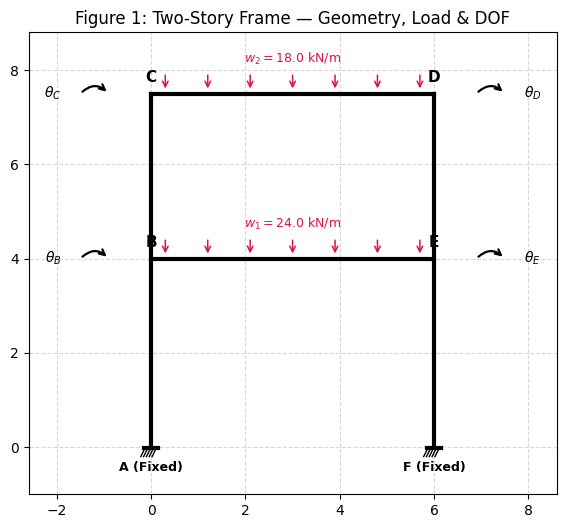

**② ⚠️ 自由度選取**（這一步選錯或漏掉，後面所有方程式都會建立在錯誤基礎上、整題全錯，是最需要覆核的一步）：

結構左右對稱、載重也左右對稱(w1、w2都是左右一致的均佈載重)，所以**整體無側移**(兩層樓的側移角都是0，不用額外設Δ這個未知量)——這點跟Case-04(側移剛架)不同，反而更接近Case-03的情況，只是多了一層樓、多了兩個轉角未知量。

四個梁柱交會的剛性節點 B、C、D、E 各自有一個轉角未知量，**不假設對稱關係**(不預設 $\theta_B=-\theta_E$ 這種鏡像關係)，讓四條節點力矩平衡方程式自己解出來——解出來的結果會自然呈現這種鏡像對稱，這是驗證答案合理性的依據，不是事先假設的捷徑。共 $\theta_B,\theta_C,\theta_D,\theta_E$ 四個未知位移量。


【步驟 2】寫出桿端彎矩方程式


**① 公式引用**（傾角變位法一般式，對任何桿件 i→j 都適用，跟結構種類無關）：

$$M_{ij} = \frac{2EI}{L}\left(2\theta_i + \theta_j - 3\psi\right) + FEM_{ij}$$

其中 $\theta_i,\theta_j$ 為兩端轉角，$\psi=\Delta/L$ 為側移角（無側移時 $\psi=0$），$FEM_{ij}$ 為固定端彎矩(依載重種類查表)。

**② 代入本題的邊界條件、跨長與載重**，得到每根桿件的具體算式：


【步驟 3】建立平衡方程式


**平衡方程式**（每條方程式對應哪個節點/桿件、哪一種平衡條件）：

- 節點 B 力矩平衡 ΣM_B=0（柱AB、柱BC、梁BE交會） M_BA+M_BC+M_BE=0

- 節點 C 力矩平衡 ΣM_C=0（柱BC與梁CD交會） M_CB+M_CD=0

- 節點 D 力矩平衡 ΣM_D=0（梁CD與柱ED交會） M_DC+M_DE=0

- 節點 E 力矩平衡 ΣM_E=0（柱FE、柱ED、梁BE交會） M_EF+M_ED+M_EB=0


【步驟 4】求解聯立方程式 (未知位移量)


**① 符號解**（保留 EI 符號，這是傾角變位法教學上的標準步驟——對單一材料/均勻EI的靜不定結構，解出來的桿端彎矩最終會跟EI無關，所以先看符號解能清楚看出這個特性）：

**② 代入 EI 數值**（EI = 15000.0，方便直接跟 anastruct、OpenSeesPy 這類數值工具的結果對照，不用自己心算分數/小數）：


【步驟 5】計算真實桿端彎矩與反力


**最終桿端彎矩計算結果 (kN·m)：**

M_{AB} = 11.330 kN·m
M_{BA} = 22.659 kN·m
M_{BC} = 41.787 kN·m
M_{CB} = 44.730 kN·m
M_{CD} = -44.730 kN·m
M_{DC} = 44.730 kN·m
M_{DE} = -44.730 kN·m
M_{ED} = -41.787 kN·m
M_{BE} = -64.447 kN·m
M_{EB} = 64.447 kN·m
M_{EF} = -22.659 kN·m
M_{FE} = -11.330 kN·m

-> H_A (kN) = 8.497
-> H_F (kN) = -8.497


{'moments': {'M_{AB}': 11.329700272479563,
  'M_{BA}': 22.659400544959126,
  'M_{BC}': 41.78746594005449,
  'M_{CB}': 44.73024523160763,
  'M_{CD}': -44.730245231607626,
  'M_{DC}': 44.730245231607626,
  'M_{DE}': -44.73024523160763,
  'M_{ED}': -41.78746594005449,
  'M_{BE}': -64.44686648501363,
  'M_{EB}': 64.44686648501363,
  'M_{EF}': -22.659400544959126,
  'M_{FE}': -11.329700272479563},
 'reactions': {'H_A (kN)': 8.497275204359672, 'H_F (kN)': -8.497275204359672},
 'solution': {theta_B: 22.6594005449591/EI,
  theta_C: 27.8092643051771/EI,
  theta_D: -27.8092643051771/EI,
  theta_E: -22.6594005449591/EI}}

In [4]:
problem = TwoStoryFrameProblem(H1=4.0, H2=3.5, L=6.0, w1=24.0, w2=18.0, EI_numeric=15000.0)
solver = SlopeDeflectionSolver(problem)
solver.solve_and_report()

## 3b. 教學講義輸出（只有五張圖：結構受力圖／剪力圖／彎矩圖／拉力側標註圖／變形圖）

### a. 結構受力圖

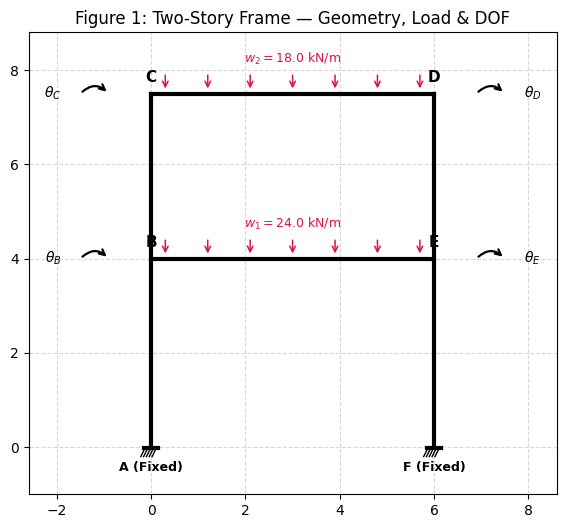

### b. 剪力圖 (SFD)

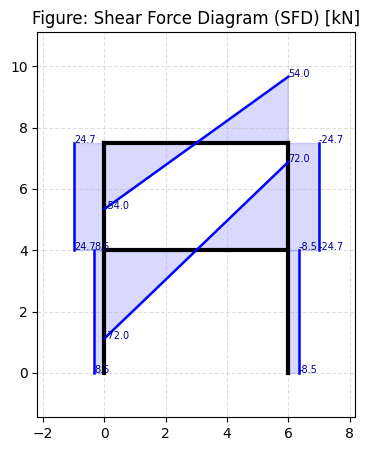

### c. 彎矩圖 (BMD)

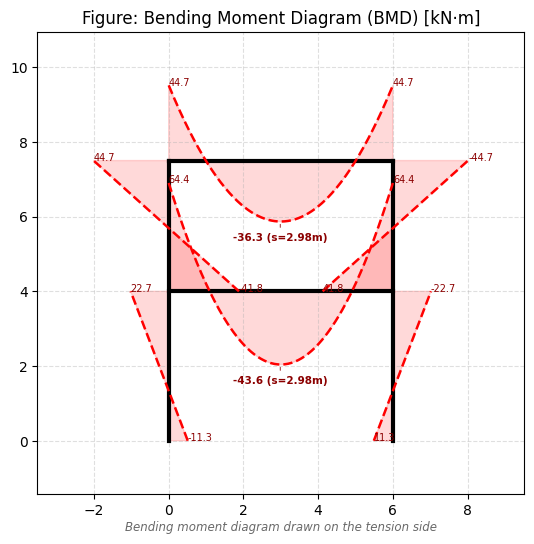

### d. 拉力側標註圖

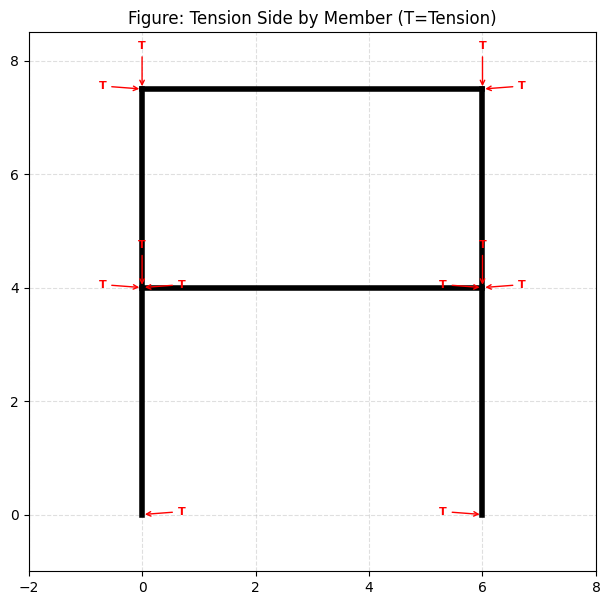

### e. 變形圖

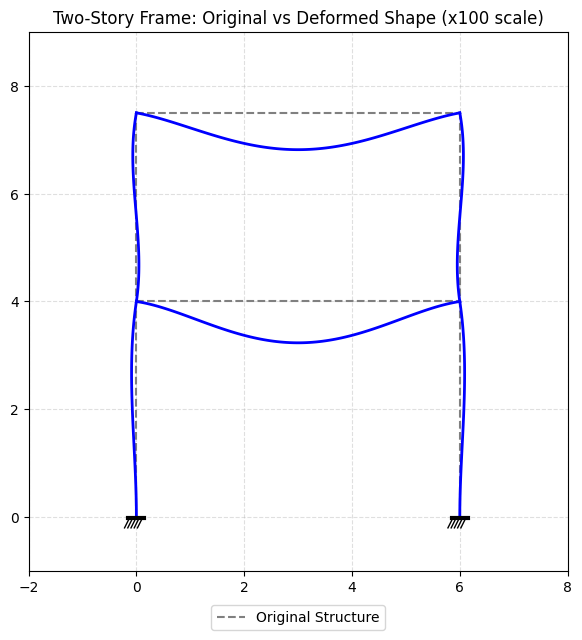

In [5]:
solver.print_teaching_handout()

## 4. anastruct 獨立建模驗證

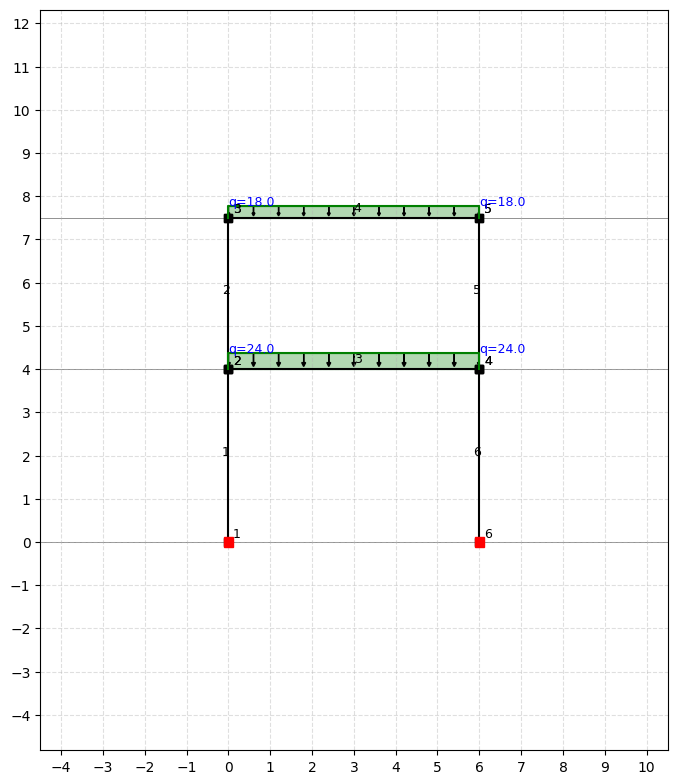

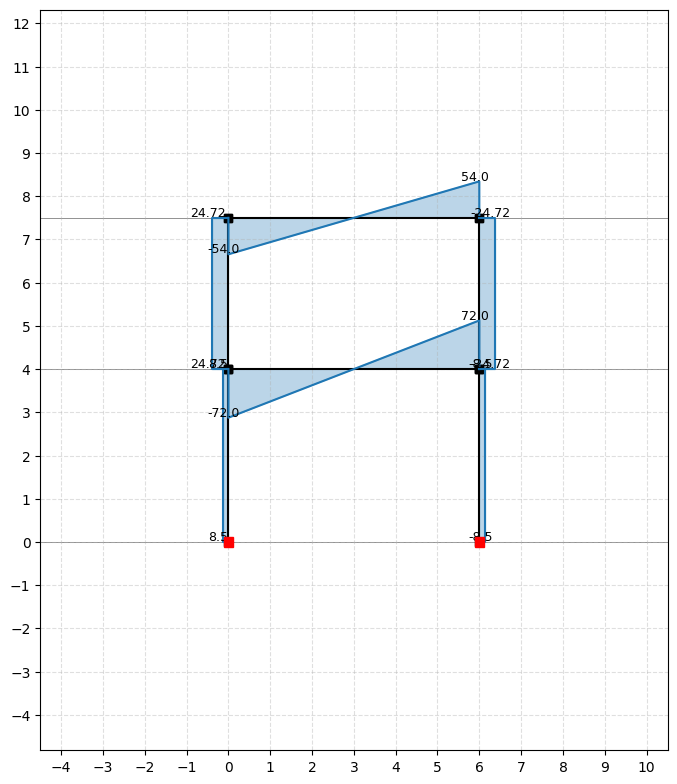

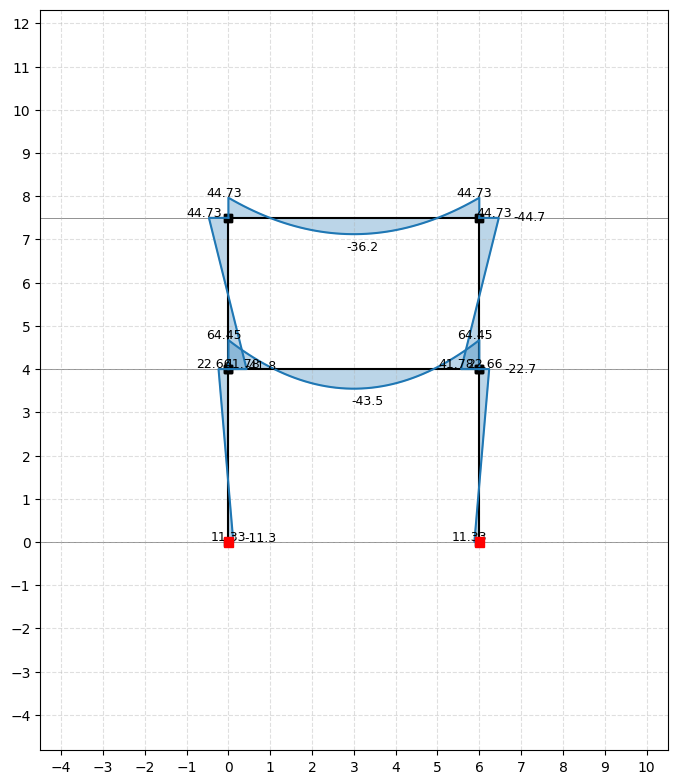

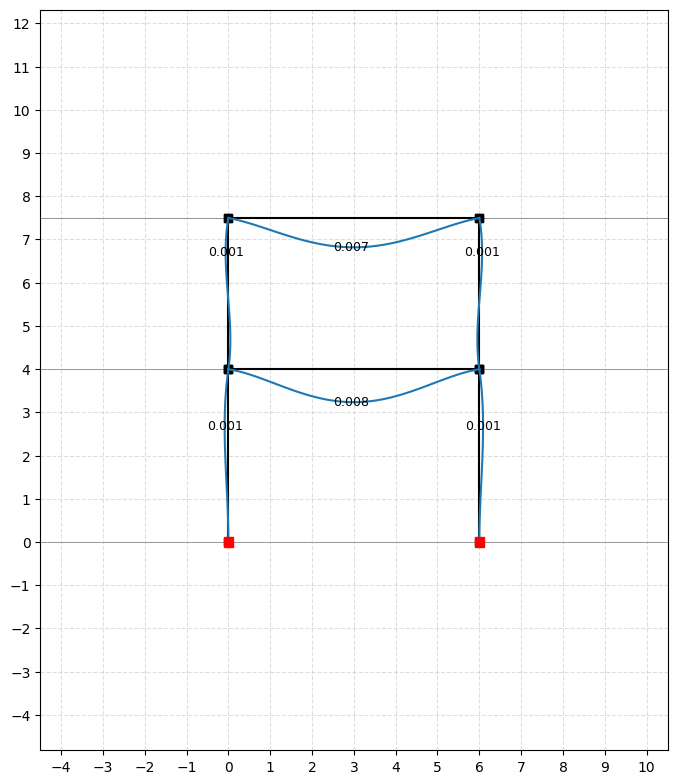

柱AB: A=-11.333 B=-22.663
柱BC: B=-41.783 C=-44.728
梁BE: B=64.446 E=-64.446
梁CD: C=44.728 D=-44.728
柱ED: E=41.783 D=44.728
柱FE: F=11.333 E=22.663


In [6]:
from anastruct import SystemElements
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

H1, H2, L, w1, w2 = 4.0, 3.5, 6.0, 24.0, 18.0
Htot = H1 + H2
ss = SystemElements(EA=1e8, EI=15000.0)
ss.add_element(location=[[0, 0], [0, H1]])           # 1: AB
ss.add_element(location=[[0, H1], [0, Htot]])         # 2: BC
ss.add_element(location=[[0, H1], [L, H1]])           # 3: BE
ss.add_element(location=[[0, Htot], [L, Htot]])       # 4: CD
ss.add_element(location=[[L, H1], [L, Htot]])         # 5: ED
ss.add_element(location=[[L, 0], [L, H1]])            # 6: FE
ss.add_support_fixed(node_id=1)  # A
ss.add_support_fixed(node_id=6)  # F
ss.q_load(element_id=3, q=-w1)
ss.q_load(element_id=4, q=-w2)
ss.solve()

def apply_grid(fig, y_lines=()):
    ax = fig.axes[0]
    ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(mticker.MultipleLocator(1))
    ax.grid(True, linestyle='--', alpha=0.4)
    for y in y_lines:
        ax.axhline(y, color='gray', lw=0.6, zorder=0)
    return fig

fig_s = ss.show_structure(show=False, figsize=(7, 8))
apply_grid(fig_s, [0, H1, Htot])
plt.show()

fig_v = ss.show_shear_force(show=False, figsize=(7, 8))
apply_grid(fig_v, [0, H1, Htot])
plt.show()

fig_m = ss.show_bending_moment(show=False, figsize=(7, 8))
apply_grid(fig_m, [0, H1, Htot])
plt.show()

fig_d = ss.show_displacement(show=False, factor=100, figsize=(7, 8))
apply_grid(fig_d, [0, H1, Htot])
plt.show()

el1,el2,el3,el4,el5,el6 = [ss.element_map[i] for i in range(1,7)]
print("柱AB: A=%.3f B=%.3f" % (el1.node_1.Tz, el1.node_2.Tz))
print("柱BC: B=%.3f C=%.3f" % (el2.node_1.Tz, el2.node_2.Tz))
print("梁BE: B=%.3f E=%.3f" % (el3.node_1.Tz, el3.node_2.Tz))
print("梁CD: C=%.3f D=%.3f" % (el4.node_1.Tz, el4.node_2.Tz))
print("柱ED: E=%.3f D=%.3f" % (el5.node_1.Tz, el5.node_2.Tz))
print("柱FE: F=%.3f E=%.3f" % (el6.node_1.Tz, el6.node_2.Tz))

## 5. 彎矩交叉檢查（十二個桿端值全部核對）

In [7]:
ours = {'AB':(11.330,22.659), 'BC':(41.787,44.730), 'BE':(-64.447,64.447),
        'CD':(-44.730,44.730), 'ED':(-41.787,-44.730), 'FE':(-11.330,-22.659)}
anastruct_raw = {'AB':(el1.node_1.Tz, el1.node_2.Tz), 'BC':(el2.node_1.Tz, el2.node_2.Tz),
                  'BE':(el3.node_1.Tz, el3.node_2.Tz), 'CD':(el4.node_1.Tz, el4.node_2.Tz),
                  'ED':(el5.node_1.Tz, el5.node_2.Tz), 'FE':(el6.node_1.Tz, el6.node_2.Tz)}
all_ok = True
for name in ours:
    o1, o2 = ours[name]
    a1, a2 = anastruct_raw[name]
    ok = abs(o1 - (-a1)) < 0.05 and abs(o2 - (-a2)) < 0.05
    all_ok = all_ok and ok
    print(f"{name}: 我們=({o1:.2f},{o2:.2f})  anastruct(取負)=({-a1:.2f},{-a2:.2f})  {'✓' if ok else '✗'}")
assert all_ok
print("\n彎矩交叉檢查通過 ✓ (六根桿件、十二個端點全部核對)")

AB: 我們=(11.33,22.66)  anastruct(取負)=(11.33,22.66)  ✓
BC: 我們=(41.79,44.73)  anastruct(取負)=(41.78,44.73)  ✓
BE: 我們=(-64.45,64.45)  anastruct(取負)=(-64.45,64.45)  ✓
CD: 我們=(-44.73,44.73)  anastruct(取負)=(-44.73,44.73)  ✓
ED: 我們=(-41.79,-44.73)  anastruct(取負)=(-41.78,-44.73)  ✓
FE: 我們=(-11.33,-22.66)  anastruct(取負)=(-11.33,-22.66)  ✓

彎矩交叉檢查通過 ✓ (六根桿件、十二個端點全部核對)
